In [1]:
# start by loading the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Packages loaded successfully")

Packages loaded successfully


In [2]:
# read the EPA data
#df = pd.read_csv('HABsDrivers_Model_Data.csv')
df = pd.read_csv("../data/HABsDrivers_Model_Data.csv")
print(' Data loaded successfully')

 Data loaded successfully


### Start with understanding the data. What actuallly I have?

In [3]:
df.shape


(3664, 72)

In [4]:
df.head()

,SITE_ID,VISIT_NO,UNIQUE_ID,DSGN_CYCLE,DATE_COL,LAT_DD83,LON_DD83,COMID,TEMPERATURE,MAXDEPTH,...,P_f_fertilizer,P_human_waste_kg,P_livestock_Waste,P_nf_fertilizer,n_farm_inputs,n_dev_inputs,p_farm_inputs,p_dev_inputs,AG_ECO3,AG_ECO9_NM
0,NLA12_CA-143,1,NLA_CA-10078,2012,05/02/2012,37.564489,-121.997182,2806117,12.00,7.8,...,0.00,29.06,0.00,2.46,0.00,NaN,0.00,31.52,WMTNS,Xeric
1,NLA12_AZ-101,1,NLA_AZ-10016,2012,05/08/2012,33.569297,-111.524143,20476542,21.53,24.0,...,0.02,0.03,0.16,0.00,0.68,0.13,0.18,0.03,WMTNS,Xeric
2,NLA12_ND-115,1,NLA_ND-10055,2012,05/16/2012,46.826042,-100.634208,14681240,17.01,8.0,...,0.00,0.06,4.14,0.23,71.36,1.60,4.14,0.29,PLNLOW,Northern Plains
3,NLA12_AZ-118,1,NLA_AZ-10057,2012,05/09/2012,33.381311,-111.883581,20479908,24.80,0.0,...,0.05,10.07,2.99,0.18,43.71,192.28,3.04,10.25,WMTNS,Xeric
4,NLA12_UT-103,1,NLA_UT-10023,2012,05/09/2012,41.518822,-111.736433,664040,12.30,33.5,...,0.01,0.09,0.02,0.01,0.17,0.55,0.03,0.10,WMTNS,Western Mountains


### Read the metadata

In [5]:
# now load the meta data:
metadata = pd.read_csv("../data/HABsDrivers_Model_Metadata.csv")
print('Meta data loaded successfully')

Meta data loaded successfully


In [6]:
metadata.shape
metadata.head()


,Variable,Description,Type,Values,Units,MissingDataValue,MissingDataMeaning
0,SITE_ID,A site ID assigned to a lake within an NLA sur...,character,NaN,NaN,NaN,NaN
1,VISIT_NO,The first or second visit to a site,integer,1 | 2,NaN,NaN,NaN
2,UNIQUE_ID,A unique ID assigned to each lake sampled acro...,character,NaN,NaN,NaN,NaN
3,DSGN_CYCLE,The year of the NLA survey cycle,integer,2007 | 2012 | 2017,NaN,NaN,NaN
4,DATE_COL,Date sample was collected,date,NaN,M/D/YYYY,NaN,NaN


In [7]:
#Inspect the columns
df.columns.tolist()

['SITE_ID',
 'VISIT_NO',
 'UNIQUE_ID',
 'DSGN_CYCLE',
 'DATE_COL',
 'LAT_DD83',
 'LON_DD83',
 'COMID',
 'TEMPERATURE',
 'MAXDEPTH',
 'STRATIFIED',
 'AMMONIA_N',
 'DO_SURF',
 'DOC',
 'NTL',
 'PTL',
 'TURB',
 'NITRATE_N',
 'PH',
 'CHLA_RESULT',
 'MICX',
 'MICX_DET',
 'B_G_DENS',
 'EVAP_INFL',
 'D_EXCESS',
 'agr_ws',
 'dev_ws',
 'fst_ws',
 'wet_ws',
 'precip_mean_month',
 'temp_mean_month',
 'lakemorpho_fetch',
 'BFIWs',
 'AgKffactWs',
 'KffactWs',
 'RunoffWs',
 'Precip_Minus_EVTWs',
 'Precip8110Ws',
 'Tmean8110Ws',
 'ElevWs',
 'SlopeWs',
 'N_CBNF',
 'N_Crop_N_Rem',
 'N_Fert_Farm',
 'N_Fert_Urban',
 'N_Forest_Fire',
 'N_Human_N_Demand',
 'N_Human_Waste',
 'N_Manure_Recov',
 'N_Rock',
 'N_Surplus',
 'N_Total_Deposition',
 'N_Total_Inputs',
 'N_Total_Outputs',
 'N_Total_nBNF',
 'N_livestock_Waste',
 'P_Accumulated_ag_inputs',
 'P_Crop_removal',
 'P_Deposition',
 'P_Legacy_P',
 'P_Recovered_P',
 'P_Surplus',
 'P_f_fertilizer',
 'P_human_waste_kg',
 'P_livestock_Waste',
 'P_nf_fertilizer',
 '

### SCheck data types and missing values

In [8]:
#SCheck data types and missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3664 entries, 0 to 3663
Data columns (total 72 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   SITE_ID                  3664 non-null   str    
 1   VISIT_NO                 3664 non-null   int64  
 2   UNIQUE_ID                3664 non-null   str    
 3   DSGN_CYCLE               3664 non-null   int64  
 4   DATE_COL                 3664 non-null   str    
 5   LAT_DD83                 3664 non-null   float64
 6   LON_DD83                 3664 non-null   float64
 7   COMID                    3664 non-null   int64  
 8   TEMPERATURE              3620 non-null   float64
 9   MAXDEPTH                 3632 non-null   float64
 10  STRATIFIED               3664 non-null   int64  
 11  AMMONIA_N                3663 non-null   float64
 12  DO_SURF                  3611 non-null   float64
 13  DOC                      3655 non-null   float64
 14  NTL                      3664 non-n

In [9]:
df.isna().sum() #this line is to calculate the missing value

SITE_ID            0
VISIT_NO           0
UNIQUE_ID          0
DSGN_CYCLE         0
DATE_COL           0
                ... 
n_dev_inputs     565
p_farm_inputs    574
p_dev_inputs     572
AG_ECO3            0
AG_ECO9_NM         0
Length: 72, dtype: int64

### The question I want to answer is which environmental factors are associated with the cyanobacterial abundance in U.S. lakes?


## To start with, I will choose four potential explanatory variable and one outcome, namely:
### 1: Cyanobacteria density (B_G_DENS)
### 2: Water temperature (TEMPERATURE)
### 3: Total phosphorus (PTL)
### 4: Total nitrogen (NTL)
### 5: Chlorophyll-a (CHLA_RESULT)
### The table below gives more information

| Variable      | Role        | Why                   |
| ------------- | ----------- | --------------------- |
| `B_G_DENS`    | **Outcome** | Cyanobacteria density |
| `TEMPERATURE` | Predictor   | Water temperature     |
| `PTL`         | Predictor   | Total phosphorus      |
| `NTL`         | Predictor   | Total nitrogen        |
| `CHLA_RESULT` | Predictor   | Chlorophyll-a         |


In [10]:
# Let's select these variable from the DataFrame
sel_var = [
    'B_G_DENS',
    'TEMPERATURE',
    'PTL',
    'NTL',
    'CHLA_RESULT'
]


In [11]:
# now investigate them:

df[sel_var].head()

,B_G_DENS,TEMPERATURE,PTL,NTL,CHLA_RESULT
0,2158.0,12.00,26.8,0.339,2.700
1,7319.0,21.53,40.0,0.321,3.228
2,3599.0,17.01,70.0,1.509,7.480
3,0.0,24.80,38.0,0.483,1.300
4,45.0,12.30,23.0,0.189,6.353


In [12]:
df[sel_var].info()

<class 'pandas.DataFrame'>
RangeIndex: 3664 entries, 0 to 3663
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   B_G_DENS     3661 non-null   float64
 1   TEMPERATURE  3620 non-null   float64
 2   PTL          3659 non-null   float64
 3   NTL          3664 non-null   float64
 4   CHLA_RESULT  3653 non-null   float64
dtypes: float64(5)
memory usage: 143.3 KB


In [13]:
df[sel_var].describe()

,B_G_DENS,TEMPERATURE,PTL,NTL,CHLA_RESULT
count,3.661000e+03,3620.000000,3659.000000,3664.000000,3653.000000
mean,2.161805e+05,23.859354,110.714694,1.124314,27.531446
std,1.028627e+06,4.382657,321.115279,2.068816,79.959188
min,0.000000e+00,0.800000,1.000000,0.010000,0.066000
25%,2.448000e+03,21.137500,14.822500,0.329000,2.968000
50%,1.970000e+04,24.200000,33.558750,0.616000,7.970000
75%,9.410000e+04,27.000000,92.000000,1.216750,25.440000
max,3.882800e+07,37.630000,11238.800000,54.000000,3299.180000


### The output shows 3664 entries, 0 to 3663
### let check for missing value, if any

In [14]:
df[sel_var].isna().sum()

B_G_DENS        3
TEMPERATURE    44
PTL             5
NTL             0
CHLA_RESULT    11
dtype: int64

### The missing values are very small: That's excellent for the analysisthere is no  serious missing-data problem.

### For the five variables together, we'll only lose a small number of rows if we eventually use complete-case analysis.

In [15]:
df['B_G_DENS'].sort_values(ascending=False).head(20)

3626    38828000.0
3407    19836230.0
3244    16568000.0
3371    12430260.0
2498     9925840.0
1071     8757487.0
3604     8655300.0
1025     8493252.0
3641     8045670.0
2993     7300700.0
715      6766108.0
3414     6535340.0
2709     6066680.0
3508     6051620.0
2681     5890342.0
748      5796307.0
2873     5777440.0
3620     5420540.0
2832     5310792.0
3587     5161900.0
Name: B_G_DENS, dtype: float64

### Now I will investigate the actual distribution using histogram

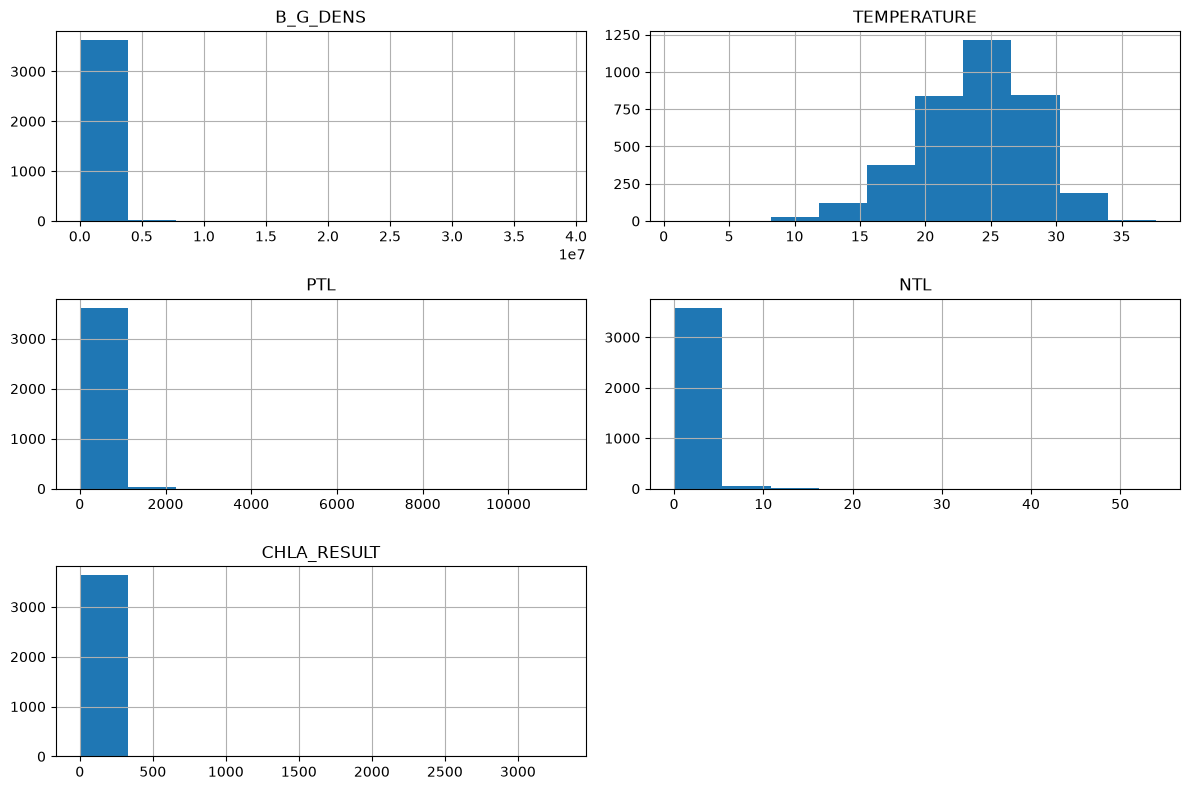

In [16]:
df[sel_var].hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

### The figures look extremely skewed
### let's look at each distribution closely

## Let's make your first important plot.

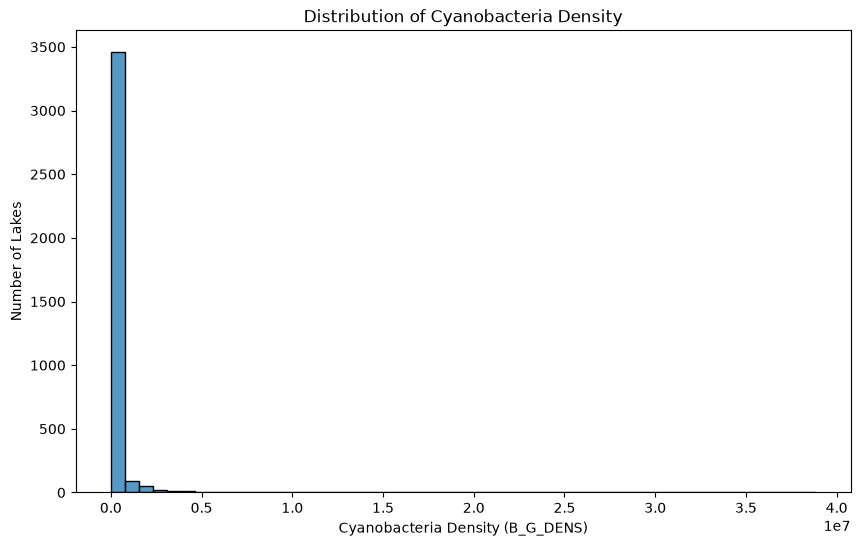

In [17]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x='B_G_DENS',
    bins=50
)

plt.title('Distribution of Cyanobacteria Density')
plt.xlabel('Cyanobacteria Density (B_G_DENS)')
plt.ylabel('Number of Lakes')

plt.show()

### It can be see most observations compressed toward the left because of the extreme values.
### This confirm when we compare the median with the maximum:
### 19,700 → 38,828,000

### What the histogram show us
### Most of the 3,664 lake observations are concentrated at relatively low B_G_DENS values.
### A small number of observations have very large cyanobacteria densities.
### The x-axis extends to roughly 40 million, which causes the majority of observations to be compressed near zero.
### This is why the ordinary histogram isn't very useful for seeing the detailed distribution of most lakes.
### An interesting findingThat's actually a useful finding. let's look into log scale

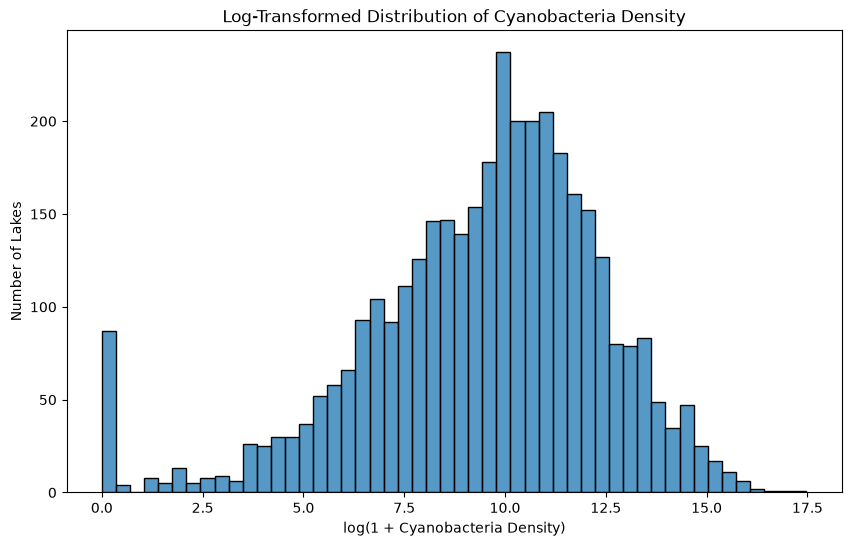

In [18]:
df['B_G_DENS_log'] = np.log1p(df['B_G_DENS']) # this is to avoid log (0) that may occur from zero values
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x='B_G_DENS_log',
    bins=50
)

plt.title('Log-Transformed Distribution of Cyanobacteria Density')
plt.xlabel('log(1 + Cyanobacteria Density)')
plt.ylabel('Number of Lakes')

plt.show()

### What can be seen The log transformation has compressed the extreme values and revealed the underlying distribution.

## A few observations stand out:

### 1: Most observations are now visible rather than being compressed against zero.
### 2: The main distribution is centered roughly around log(1 + B_G_DENS) = 10–12.
### 3: There is still a group at 0, representing lakes where B_G_DENS = 0.
### 4: There are some lower-density observations between roughly 1–5.
### 5: The distribution is much closer to a roughly bell-shaped distribution, although it isn't perfectly normal.

### This is a strong reason to use B_G_DENS_log for visualizations and correlation analysis, while keeping the original B_G_DENS for interpretation.

In [19]:
### Important distinction

## I haven't "fixed" the data by transforming it. I created another variable:

df['B_G_DENS_log'] = np.log1p(df['B_G_DENS'])

## So we still have:

## B_G_DENS       → original scientific measurement
## B_G_DENS_log   → transformed variable for analysis/visualization

### Let's plot the other varible

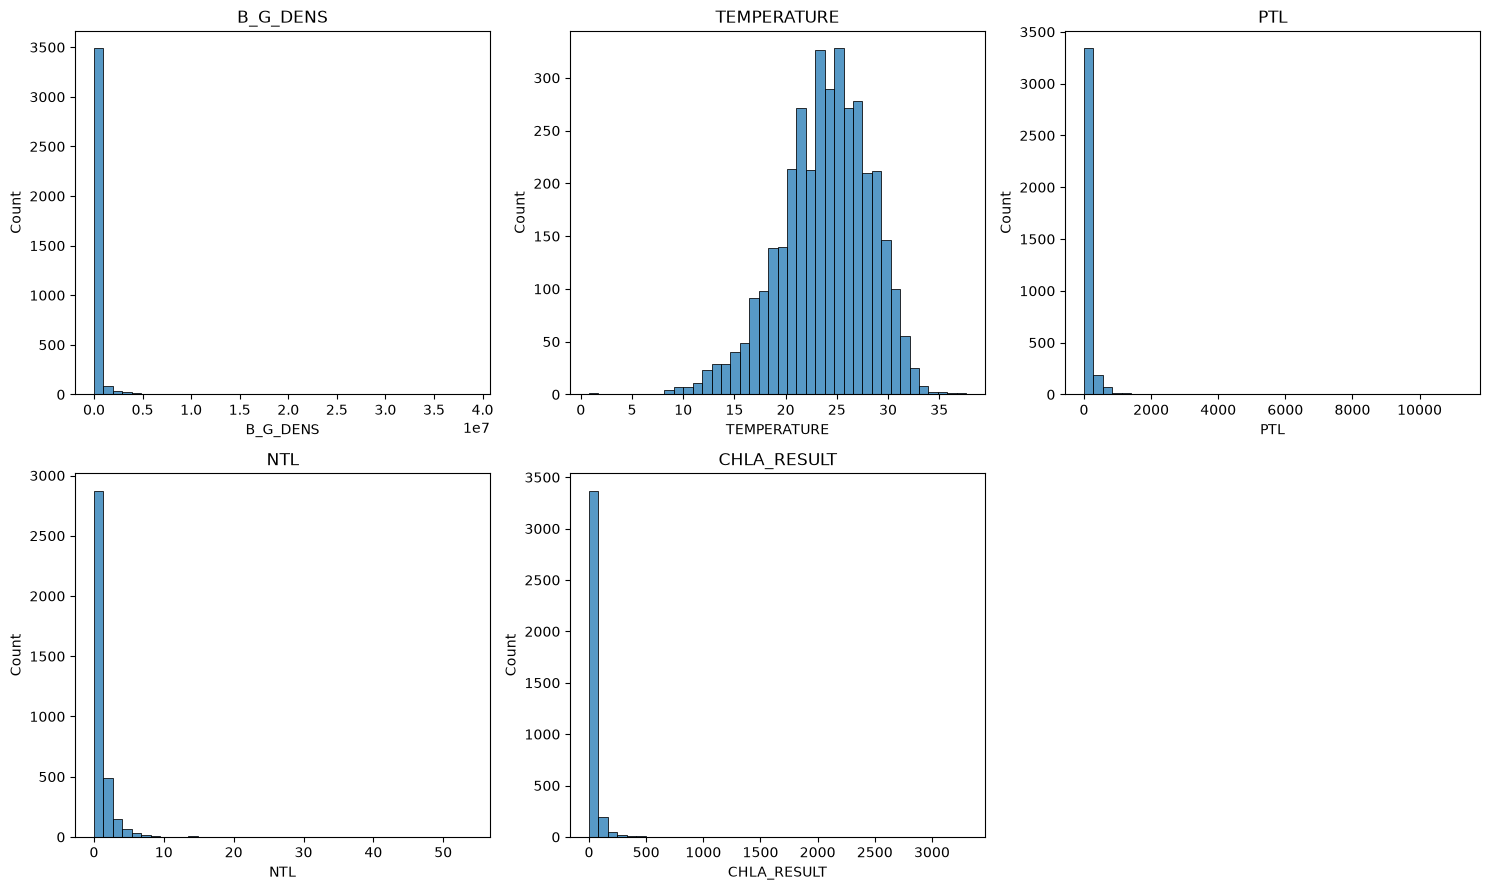

In [20]:


fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, variable in zip(
    axes.flatten(),
    ['B_G_DENS', 'TEMPERATURE', 'PTL', 'NTL', 'CHLA_RESULT']
):
    sns.histplot(data=df, x=variable, bins=40, ax=ax)
    ax.set_title(variable)

axes[-1, -1].axis('off')

plt.tight_layout()
plt.show()

### The figures show that the varliables are right-skewed except the tempterature,
### Let perform the long transform and plot the results *_-


In [21]:
df['PTL_log'] = np.log1p(df['PTL'])
df['NTL_log'] = np.log1p(df['NTL'])
df['CHLA_RESULT_log'] = np.log1p(df['CHLA_RESULT'])

In [22]:
# run the check
df[['PTL', 'PTL_log', 'NTL', 'NTL_log', 'CHLA_RESULT', 'CHLA_RESULT_log']].describe()

,PTL,PTL_log,NTL,NTL_log,CHLA_RESULT,CHLA_RESULT_log
count,3659.000000,3659.000000,3664.000000,3664.000000,3653.000000,3653.000000
mean,110.714694,3.683897,1.124314,0.606044,27.531446,2.397913
std,321.115279,1.327558,2.068816,0.459262,79.959188,1.278158
min,1.000000,0.693147,0.010000,0.009950,0.066000,0.063913
25%,14.822500,2.761432,0.329000,0.284427,2.968000,1.378262
50%,33.558750,3.542661,0.616000,0.479954,7.970000,2.193886
75%,92.000000,4.532599,1.216750,0.796042,25.440000,3.274878
max,11238.800000,9.327216,54.000000,4.007333,3299.180000,8.101732


### plot the transform dist.


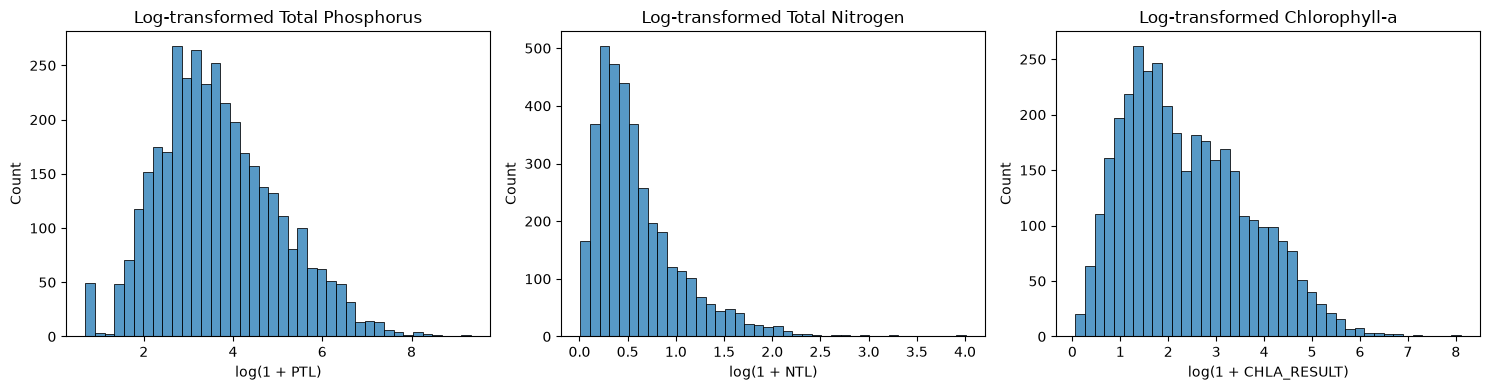

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df['PTL_log'].dropna(), bins=40, ax=axes[0])
axes[0].set_title('Log-transformed Total Phosphorus')
axes[0].set_xlabel('log(1 + PTL)')

sns.histplot(df['NTL_log'].dropna(), bins=40, ax=axes[1])
axes[1].set_title('Log-transformed Total Nitrogen')
axes[1].set_xlabel('log(1 + NTL)')

sns.histplot(df['CHLA_RESULT_log'].dropna(), bins=40, ax=axes[2])
axes[2].set_title('Log-transformed Chlorophyll-a')
axes[2].set_xlabel('log(1 + CHLA_RESULT)')

plt.tight_layout()
plt.show()

### We have obtained useful information

 | Variable      | Original                   | After `log1p()`                  | Decision               |
 | ------------- | -------------------------- | -------------------------------- | ---------------------- |
 | `B_G_DENS`    | Very strongly right-skewed | Much more balanced               | **Use log**            |
 | `PTL`         | Right-skewed               | Approximately normal-ish         | **Use log**            |
 | `NTL`         | Right-skewed               | Still right-skewed               | **Keep investigating** |
 | `CHLA_RESULT` | Strongly right-skewed      | Improved, but still right-skewed | **Use log**            |
 | `TEMPERATURE` | Approximately normal       | —                                | **Keep original**      |

#### For NTL, I wouldn'tapply another transformation. The fact that it remains skewed is itself a characteristic of the environmental data.


### Now, I will quantify the skewness rather than relying only on visual interpretation.
### As a rough guide:

### 0 → symmetric
### positive → right-skewed
### negative → left-skewed
### around -0.5 to +0.5 → often considered reasonably symmetric
### 1 → substantially right-skewed

In [24]:
# This code will calculate the skewness value for each var.
selected_transformed = [
    'B_G_DENS_log',
    'PTL_log',
    'NTL_log',
    'CHLA_RESULT_log',
    'TEMPERATURE'
]

df[selected_transformed].skew()

B_G_DENS_log      -0.835335
PTL_log            0.451619
NTL_log            1.778180
CHLA_RESULT_log    0.555576
TEMPERATURE       -0.485985
dtype: float64

### Interpretation

| Variable          |   Skewness | Interpretation                              |
| ----------------- | ---------: | ------------------------------------------- |
| `B_G_DENS_log`    | **-0.835** | Moderately left-skewed after transformation |
| `PTL_log`         |  **0.452** | Quite reasonably symmetric                  |
| `NTL_log`         |  **1.778** | Still strongly right-skewed                 |
| `CHLA_RESULT_log` |  **0.556** | Reasonably close to symmetric               |
| `TEMPERATURE`     | **-0.486** | Approximately symmetric                     |


### As expected, the results confirm my analysis and conclusion.

## Correlation analysis

### Now I want to ask:

### How are these five environmental variables related to cyanobacteria density?

### I will first calculate Pearson correlation using our analysis versions:

In [25]:
corr_vars = [
    'B_G_DENS_log',
    'TEMPERATURE',
    'PTL_log',
    'NTL_log',
    'CHLA_RESULT_log'
]

pearson_corr = df[corr_vars].corr(method='pearson')

#print(f"The correlation matrix is:\n{pearson_corr}")
print("The correlation matrix is:")
print(pearson_corr)

The correlation matrix is:
                 B_G_DENS_log  TEMPERATURE   PTL_log   NTL_log  \
B_G_DENS_log         1.000000     0.167308  0.356212  0.385351   
TEMPERATURE          0.167308     1.000000  0.087062  0.058226   
PTL_log              0.356212     0.087062  1.000000  0.755058   
NTL_log              0.385351     0.058226  0.755058  1.000000   
CHLA_RESULT_log      0.501492     0.290181  0.706788  0.671912   

                 CHLA_RESULT_log  
B_G_DENS_log            0.501492  
TEMPERATURE             0.290181  
PTL_log                 0.706788  
NTL_log                 0.671912  
CHLA_RESULT_log         1.000000  


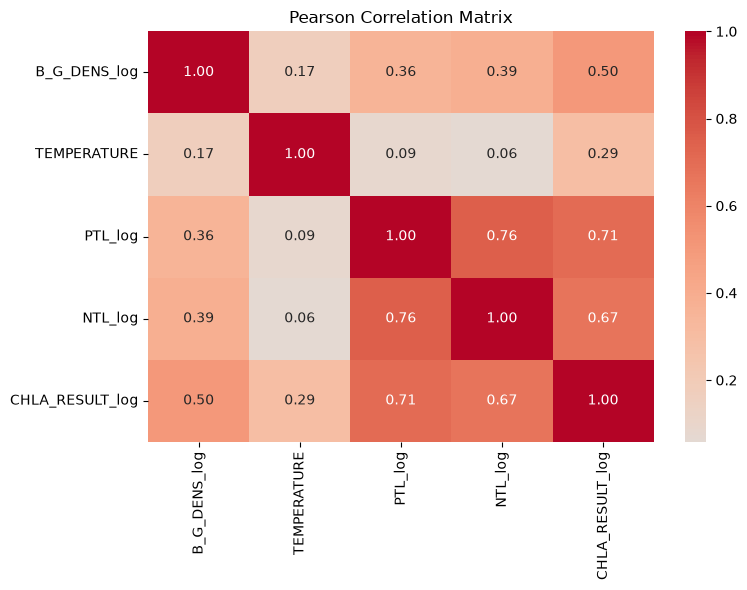

In [26]:
# Let's visualize it:

plt.figure(figsize=(8, 6))

sns.heatmap(
    pearson_corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Pearson Correlation Matrix')
plt.tight_layout()
plt.show()

### Then I'll do Spearman
### 

In [27]:
spearman_corr = df[corr_vars].corr(method='spearman')

spearman_corr

,B_G_DENS_log,TEMPERATURE,PTL_log,NTL_log,CHLA_RESULT_log
B_G_DENS_log,1.000000,0.123606,0.405714,0.468527,0.532782
TEMPERATURE,0.123606,1.000000,0.097772,0.148452,0.310158
PTL_log,0.405714,0.097772,1.000000,0.789308,0.725751
NTL_log,0.468527,0.148452,0.789308,1.000000,0.707617
CHLA_RESULT_log,0.532782,0.310158,0.725751,0.707617,1.000000


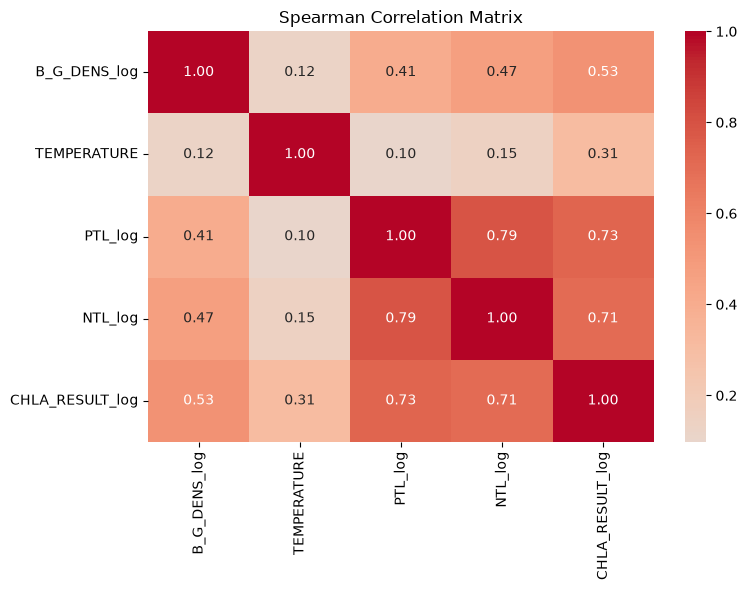

In [28]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    spearman_corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Spearman Correlation Matrix')
plt.tight_layout()
plt.show()

###  I have used these to correlation measures for two purposes:

### 1- Pearson asks roughly:

#### Is there a linear relationship?


### 2- Spearman asks:

#### Do the variables generally increase or decrease together, even if the relationship isn't linear?

#### Because NTL remains strongly skewed and B_G_DENS has extreme observations, Spearman may give us a more robust picture of the relationships

### so this is particularly useful for dataset.

### So, the result from the matrix above produced several important observations about the four variables, chlorophyll-a has the strongest association with cyanobacteria density, followed by nitrogen and phosphorus. Temperature has only a weak association. Table below shows the relationship between the fourth variables and cyanobacteria density.

### There is another important finding in your matrices: the predictors themselves are correlated. For example, Pearson gives PTL_log–NTL_log = 0.76 and PTL_log–CHLA_RESULT_log = 0.71. Spearman gives similar results. This is worth mentioning because if I later build a regression model, multicollinearity will need to be considered.

### Also notice that Pearson and Spearman give broadly similar conclusions. That's encouraging: the relationships aren't appearing only because of a few extreme observations.

| Variable vs `B_G_DENS_log` |  Pearson | Spearman | Interpretation                  |
| -------------------------- | -------: | -------: | ------------------------------- |
| `TEMPERATURE`              |     0.17 |     0.12 | Weak positive                   |
| `PTL_log`                  |     0.36 |     0.41 | Moderate positive               |
| `NTL_log`                  |     0.39 |     0.47 | Moderate positive               |
| `CHLA_RESULT_log`          | **0.50** | **0.53** | Strongest positive relationship |


### Next step is Scatter Plot which will help to get a clear picture: I will start with the strongest one

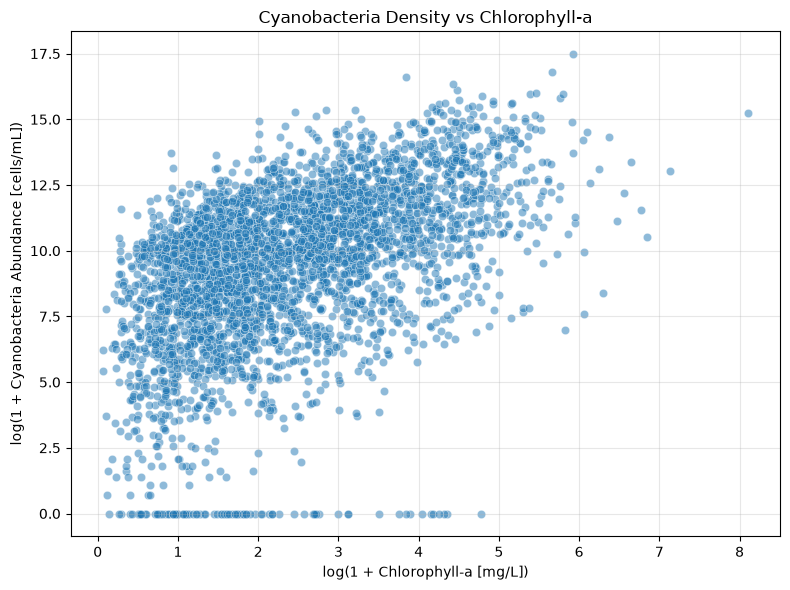

In [29]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x='CHLA_RESULT_log',
    y='B_G_DENS_log',
    alpha=0.5
)

plt.title('Cyanobacteria Density vs Chlorophyll-a')
plt.xlabel('log(1 + Chlorophyll-a [mg/L])')
plt.ylabel('log(1 + Cyanobacteria Abundance [cells/mL])')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

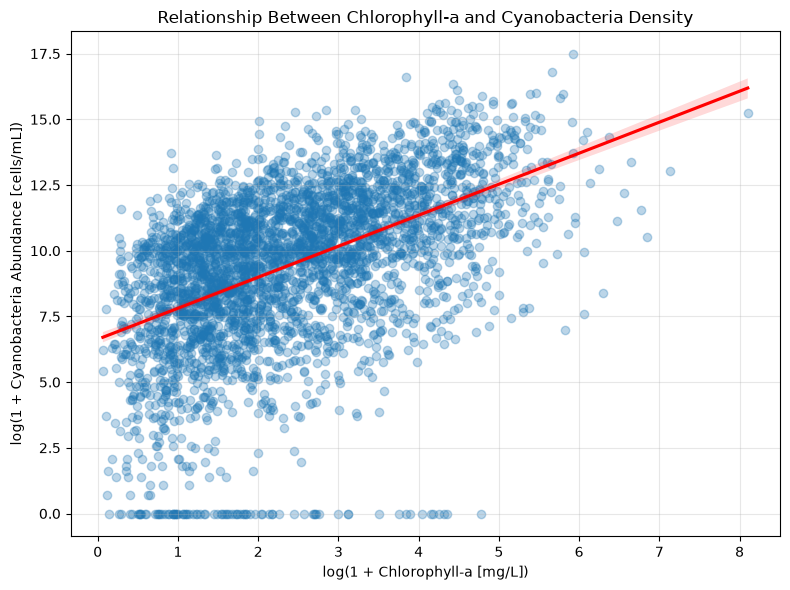

In [30]:

plt.figure(figsize=(8, 6))

sns.regplot(
    data=df,
    x='CHLA_RESULT_log',
    y='B_G_DENS_log',
    scatter_kws={'alpha': 0.3},
    line_kws={'color': 'red'}
)

plt.title('Relationship Between Chlorophyll-a and Cyanobacteria Density')
plt.xlabel('log(1 + Chlorophyll-a [mg/L])')
plt.ylabel('log(1 + Cyanobacteria Abundance [cells/mL])')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Observation: The scatter plot indicates a moderate positive association between chlorophyll-a and cyanobacteria density. Higher chlorophyll-a concentrations generally correspond to higher cyanobacteria density. This is consistent with the Pearson (r = 0.50) and Spearman (ρ = 0.53) correlation coefficients. However, substantial variability remains, indicating that chlorophyll-a alone does not fully explain variation in cyanobacteria density.

### Next, I will investigate the other three variables

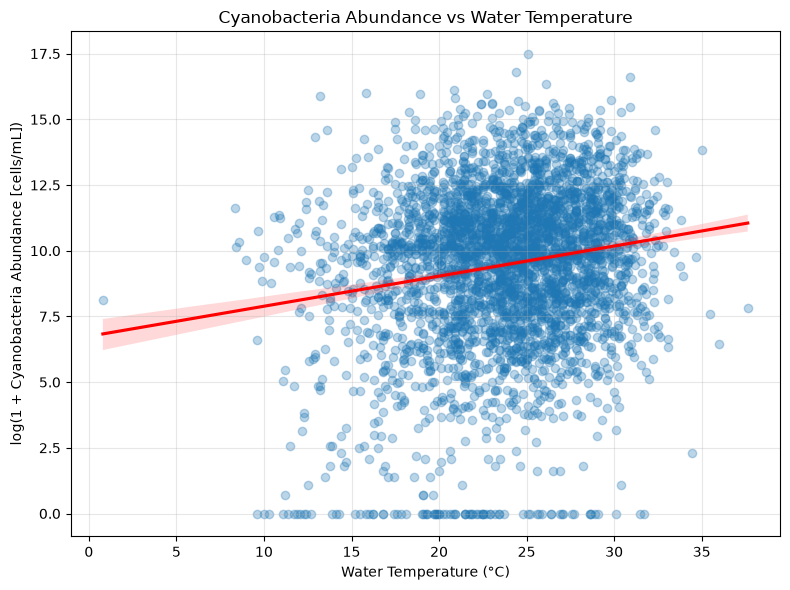

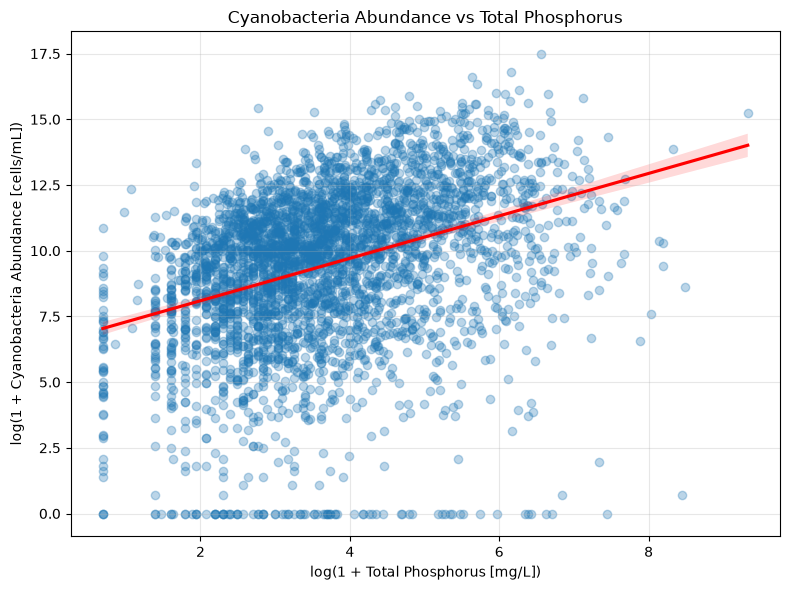

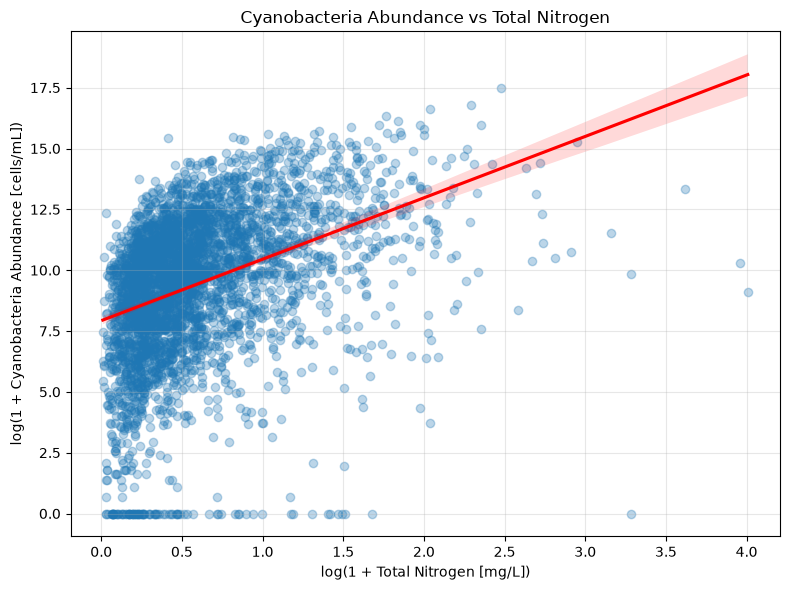

In [31]:
# Variables to plot
variables = [
    'TEMPERATURE',
    'PTL_log',
    'NTL_log'
]

# Professional names for each variable
labels = {
    'TEMPERATURE': 'Water Temperature (°C)',
    'PTL_log': 'log(1 + Total Phosphorus [mg/L])',
    'NTL_log': 'log(1 + Total Nitrogen [mg/L])'
}

# Names to use in plot titles
titles = {
    'TEMPERATURE': 'Water Temperature',
    'PTL_log': 'Total Phosphorus',
    'NTL_log': 'Total Nitrogen'
}

for variable in variables:

    plt.figure(figsize=(8, 6))

    sns.regplot(
        data=df,
        x=variable,
        y='B_G_DENS_log',
        scatter_kws={'alpha': 0.3},
        line_kws={'color': 'red'}
    )

    plt.title(f'Cyanobacteria Abundance vs {titles[variable]}')

    plt.xlabel(labels[variable])

    plt.ylabel('log(1 + Cyanobacteria Abundance [cells/mL])')

    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

### As expected: These three plots are consistent with the correlation matrices, and they provide a clearer picture of the relationships.

### Temperature → Cyanobacteria density: The regression line slopes upward, but the points are very widely scattered. This supports the weak Pearson correlation of 0.17. Temperature alone has only a weak positive association with cyanobacteria density in these observations.

### Total phosphorus (PTL_log) → Cyanobacteria density: There is a much clearer upward trend. This agrees with Pearson r = 0.36 and Spearman ρ = 0.41. I'd describe this as a moderate positive association.

### Total nitrogen (NTL_log) → Cyanobacteria density: This also shows a noticeable positive relationship and appears somewhat stronger than phosphorus, consistent with Pearson r = 0.39 and Spearman ρ = 0.47. Again, a moderate positive association.


### Combined with your chlorophyll-a result, your ranking is therefore:

### Chlorophyll-a (0.50) > Nitrogen (0.39) > Phosphorus (0.36) > Temperature (0.17) using Pearson correlation.

## Conclusion: 
The exploratory analysis indicates that cyanobacteria abundance is positively associated with chlorophyll-a, total nitrogen, total phosphorus, and water temperature. Chlorophyll-a showed the strongest association with cyanobacteria abundance, followed by total nitrogen and total phosphorus, while temperature showed only a weak positive relationship. Log transformations improved the distributions of several highly skewed environmental variables and made the relationships easier to visualise. These findings describe associations rather than causal relationships. Future work will extend this analysis using regression modelling to investigate the combined contribution of the environmental predictors to cyanobacteria abundance.

## Future Work

The next stage of this project will develop regression models to predict cyanobacteria abundance using environmental variables such as temperature, total phosphorus, total nitrogen, and chlorophyll-a. Model assumptions, multicollinearity, performance metrics, and validation will also be investigated.

In [32]:
print('Part one is finished')

Part one is finished



## Part 2: Predictive Regression Modelling

### This section develops regression models to predict log-transformed 
### cyanobacterial abundance (`B_G_DENS_log`) from selected environmental 
### and water-quality variables.

## Step 1: Create the modelling dataframe:

In [33]:
# Create the modelling dataframe:

model_vars = [
    'B_G_DENS_log',
    'TEMPERATURE',
    'PTL_log',
    'NTL_log',
    'CHLA_RESULT_log'
]

model_df = df[model_vars].dropna()

print("Original rows:", len(df))
print("Rows used for modelling:", len(model_df))

model_df.head()
print("Modelling dataset shape:", model_df.shape)

Original rows: 3664
Rows used for modelling: 3601
Modelling dataset shape: (3601, 5)


## Step 2: Define X and y

### For the model:

### y = what I want to predict → cyanobacterial abundance
### X = the environmental variables we use to predict it

In [34]:
# Define X & y
X = model_df[
    [
        'TEMPERATURE',
        'PTL_log',
        'NTL_log',
        'CHLA_RESULT_log'
    ]
]

y = model_df['B_G_DENS_log']

In [35]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X.head()

X shape: (3601, 4)
y shape: (3601,)


,TEMPERATURE,PTL_log,NTL_log,CHLA_RESULT_log
0,12.00,3.325036,0.291923,1.308333
1,21.53,3.713572,0.278389,1.441729
2,17.01,4.262680,0.919884,2.137710
3,24.80,3.663562,0.394067,0.832909
4,12.30,3.178054,0.173113,1.995108


### The regression model will try to learn the following relationship:
$$
\text{Cyanobacterial Abundance}
=
f(\text{Temperature},\ \text{Total Phosphorus},\ \text{Total Nitrogen},\ \text{Chlorophyll-a})
$$

### Because the data is transformed, I use the following environmental variables to predict log-transformed cyanobacterial abundance: 
$$
\log(1 + \text{Cyanobacterial Abundance})
=
f(\text{Temperature},\ \log(1+\text{Total Phosphorus}),\
\log(1+\text{Total Nitrogen}),\
\log(1+\text{Chlorophyll-a}))
$$

## Step 3 — Train/test split

## Train-Test Split

### I split the modelling dataset into training and test sets. I use 80% of the observations to train the regression model and reserve the remaining 20% for evaluating its performance on unseen data.

### This separation helps assess whether the model generalises beyond the observations used during training.

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2880, 4)
X_test shape: (721, 4)
y_train shape: (2880,)
y_test shape: (721,)


## Step 4: Multiple Linear Regression

## Multiple Linear Regression

### I first fit a multiple linear regression model as a baseline for predictinglog-transformed cyanobacterial abundance from water temperature, total phosphorus, total nitrogen, and chlorophyll-a.

### The model can be expressed as:

$$
\hat{y}
=
\beta_0
+\beta_1X_{\mathrm{Temperature}}
+\beta_2X_{\mathrm{PTL\_log}}
+\beta_3X_{\mathrm{NTL\_log}}
+\beta_4X_{\mathrm{CHLA\_log}}
$$

### where $\hat{y}$ represents the predicted log-transformed cyanobacterial abundance and the $\beta$ coefficients are estimated from the training data.

In [37]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[ 0.04,-0.09, 0.77, 1.02]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['TEMPERATURE','PTL_log','NTL_log','CHLA_RESULT_log']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,6.058
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,4


In [38]:
# Inspect what the modellearned from data:
print("Intercept:", linear_model.intercept_)

for variable, coefficient in zip(X.columns, linear_model.coef_):
    print(f"{variable}: {coefficient:.4f}")

Intercept: 6.057822959366387
TEMPERATURE: 0.0359
PTL_log: -0.0938
NTL_log: 0.7727
CHLA_RESULT_log: 1.0151


## What do these coefficients mean?
### The sign tells the direction of the relationship after accounting for the other predictors.


| Predictor         | Coefficient | Interpretation                                                                         |
| ----------------- | ----------: | -------------------------------------------------------------------------------------- |
| Temperature       |     +0.0359 | Higher temperature is associated with higher predicted cyanobacterial abundance        |
| PTL_log         |     −0.0938 | Phosphorus has a small negative coefficient after controlling for the other predictors |
| NTL_log         |     +0.7727 | Nitrogen has a substantial positive association                                        |
| CHLA_RESULT_log |     +1.0151 | Chlorophyll-a has a strong positive association                                        |

### So, my initial interpretation:

### The fitted linear regression model produced positive coefficients for temperature, total nitrogen, and chlorophyll-a. Total phosphorus produced a small negative coefficient despite showing a positive bivariate correlation with cyanobacterial abundance during the exploratory analysis.

### Because several predictor variables are strongly correlated with one another, particularly the nutrient and chlorophyll-a variables, I will investigate multicollinearity before drawing conclusions from the individual regression coefficients.


## Step 5 — Check multicollinearity with VIF

### Because several environmental predictors are correlated with one another, I assess multicollinearity using the Variance Inflation Factor (VIF).

### VIF measures how strongly each predictor can be explained by the other predictors in the model. High VIF values may indicate that individual regression coefficients are unstable or difficult to interpret independently.



### VIF measures how strongly each predictor can be explained by the other predictors.

## A useful rule of thumb is:

### VIF ≈ 1: essentially no multicollinearity
### 1–5: generally acceptable
### 5–10: potentially problematic
### >10: strong multicollinearity and worth investigating carefully

In [39]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [40]:
import pandas as pd

vif_data = pd.DataFrame()

vif_data["Variable"] = X_train.columns

vif_data["VIF"] = [
    variance_inflation_factor(X_train.values, i)
    for i in range(X_train.shape[1])
]

vif_data

,Variable,VIF
0,TEMPERATURE,1.144476
1,PTL_log,2.817701
2,NTL_log,2.561885
3,CHLA_RESULT_log,2.492698


## VIF Results

### The VIF values ranged from approximately 1.14 to 2.82. Temperature had the lowest VIF (1.14), while total phosphorus had the highest (2.82). All VIF values were below commonly used thresholds for problematic multicollinearity.

### Although total phosphorus, total nitrogen, and chlorophyll-a showed relatively strong pairwise correlations during the exploratory analysis, the VIF results suggest that multicollinearity is not severe enough to justify removing any of the predictors at this stage. Therefore, I retain all four predictors in the baseline linear regression model.

## Step 6: Evaluate the model on unseen data

In [41]:
y_pred = linear_model.predict(X_test)

In [42]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"R²: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")

R²: 0.2477
RMSE: 2.5803
MAE: 1.9562


## Baseline Model Performance

### The multiple linear regression model was evaluated on the held-out test set using R², root mean squared error (RMSE), and mean absolute error (MAE).

### The model achieved:

- **R² = 0.248**
- **RMSE = 2.580**
- **MAE = 1.956**

### The R² indicates that the four-predictor linear model explains approximately 24.8% of the variation in log-transformed cyanobacterial abundance in the unseen test data.

### The RMSE is higher than the MAE, indicating that larger prediction errors have a noticeable influence on model performance. Because the response variable was log-transformed, both RMSE and MAE are expressed on the transformed scale.

### I treat this linear regression model as a baseline against which more flexible predictive models can be compared.

### Step 7: Actual vs Predicted Values

### Actual vs Predicted Values

### I compare the model's predicted values with the observed values in the test set to visually assess predictive performance.

### For a model with perfect predictions, all observations would lie on the 45-degree reference line where predicted values equal observed values.

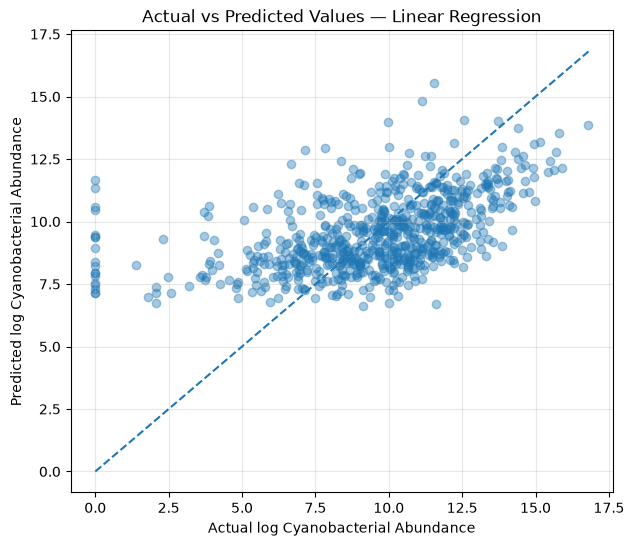

In [43]:
plt.figure(figsize=(7, 6))

plt.scatter(y_test, y_pred, alpha=0.4)

# Perfect-prediction reference line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle='--'
)

plt.xlabel('Actual log Cyanobacterial Abundance')
plt.ylabel('Predicted log Cyanobacterial Abundance')
plt.title('Actual vs Predicted Values — Linear Regression')

plt.grid(True, alpha=0.3)
plt.show()

### Actual vs Predicted Interpretation

### The actual-versus-predicted plot shows that the linear regression model captures the overall positive relationship between the observed and predicted log-transformed cyanobacterial abundance values. However, substantial dispersion around the perfect-prediction line remains.

### The predictions also appear compressed toward the middle of the observed range. In particular, the model tends to overpredict observations with very low cyanobacterial abundance and underpredict some observations with high cyanobacterial abundance.

### This pattern, together with the test R² of 0.248, suggests that the linear model captures some of the variation in cyanobacterial abundance but does not fully represent the underlying relationships in the data.

## Residual plot 
### Now calculate the residuals according to:

$$ Residual=Actual−Predicted $$

### Where  positive residual = underprediction, while negative residual = overprediction.

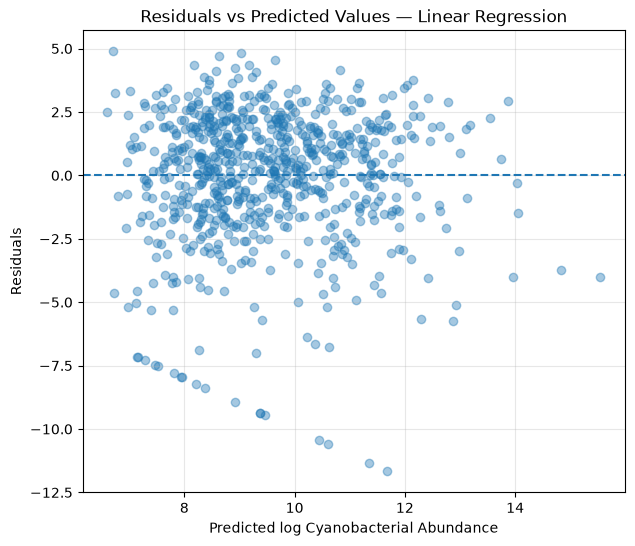

In [44]:
residuals = y_test - y_pred # define the residual
plt.figure(figsize=(7, 6))

plt.scatter(y_pred, residuals, alpha=0.4)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel('Predicted log Cyanobacterial Abundance')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values — Linear Regression')

plt.grid(True, alpha=0.3)
plt.show()

## Residual Analysis

### The residual plot shows considerable dispersion around the zero-residual reference line. Although many residuals are concentrated around zero, several large negative residuals are present, indicating substantial overprediction for some observations.

### The residuals also show a relatively long negative tail and the spread of errors is not completely uniform across the predicted range. Together with the actual-versus-predicted plot and the test R² of 0.248, these results indicate that the baseline linear regression captures only part of the variation in log-transformed cyanobacterial abundance.

### This motivates comparison with a more flexible nonlinear model that may capture relationships not represented by the linear regression.

## Step 8: Random Forest Regression

### Random Forest Regression

### To investigate whether a more flexible model can improve predictive performance, I fit a Random Forest Regressor using the same training and test sets as the baseline linear regression.

### Random Forest combines predictions from multiple decision trees and can capture nonlinear relationships and interactions among predictors without requiring these relationships to be specified explicitly.

### Using the same train-test split allows direct comparison with the baseline linear regression model.

In [45]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

## Here's what those settings mean:

### n_estimators=300 → build 300 decision trees
### random_state=42 → makes the result reproducible
### n_jobs=-1 → allows scikit-learn to use all available CPU cores to train faster

### I am starting with a straightforward Random Forest rather than immediately tuning many hyperparameters. It gives me another baseline to compare against linear regression.

### Make predictions and evaluate

In [46]:
rf_pred = rf_model.predict(X_test)

rf_r2 = r2_score(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae = mean_absolute_error(y_test, rf_pred)

print(f"Random Forest R²: {rf_r2:.4f}")
print(f"Random Forest RMSE: {rf_rmse:.4f}")
print(f"Random Forest MAE: {rf_mae:.4f}")

Random Forest R²: 0.1959
Random Forest RMSE: 2.6676
Random Forest MAE: 2.0286


## Initial Random Forest Performance

### The initial Random Forest model achieved an R² of 0.196, RMSE of 2.668, and MAE of 2.029 on the test set.

### Contrary to expectations, the Random Forest did not outperform the baseline linear regression. The linear model achieved a higher test R² and lower RMSE and MAE.

### This demonstrates that increased model flexibility does not necessarily improve generalisation. Before tuning the Random Forest, I examine its training performance to determine whether the model may be overfitting the training data.

In [47]:
### I will investigate the overfitting

In [48]:
rf_train_pred = rf_model.predict(X_train)

rf_train_r2 = r2_score(y_train, rf_train_pred)
rf_train_rmse = np.sqrt(mean_squared_error(y_train, rf_train_pred))
rf_train_mae = mean_absolute_error(y_train, rf_train_pred)

print(f"Training R²: {rf_train_r2:.4f}")
print(f"Training RMSE: {rf_train_rmse:.4f}")
print(f"Training MAE: {rf_train_mae:.4f}")

print("\nTest R²:", f"{rf_r2:.4f}")
print("Test RMSE:", f"{rf_rmse:.4f}")
print("Test MAE:", f"{rf_mae:.4f}")

Training R²: 0.8969
Training RMSE: 0.9659
Training MAE: 0.7429

Test R²: 0.1959
Test RMSE: 2.6676
Test MAE: 2.0286


| Dataset      |         R² |       RMSE |        MAE |
| ------------ | ---------: | ---------: | ---------: |
| **Training** | **0.8969** | **0.9659** | **0.7429** |
| **Test**     | **0.1959** | **2.6676** | **2.0286** |


## Random Forest Overfitting Assessment

### The Random Forest showed substantially different performance between the training and test datasets.

- **Training R² = 0.897**
- **Test R² = 0.196**
- **Training RMSE = 0.966**
- **Test RMSE = 2.668**
- **Training MAE = 0.743**
- **Test MAE = 2.029**

### The large difference between training and test performance provides strong evidence of overfitting. The model captures approximately 89.7% of the variation in the training data but only 19.6% in the unseen test data.

### This suggests that the initial Random Forest is too flexible and learns patterns specific to the training observations that do not generalise well to the test set. I therefore apply regularisation through hyperparameter tuning before making a final comparison with the linear regression model.

In [49]:
## Next: how about reducing  overfitting

### Rather than randomly changing parameters, I'll start with one of the most important ones: tree depth.

### The  current Random Forest effectively allows trees to grow without an explicit maximum depth according to: max_depth=None 

In [50]:
depth_results = []

for depth in [3, 5, 7, 10, 15, None]:

    model = RandomForestRegressor(
        n_estimators=300,
        max_depth=depth,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    depth_results.append({
        'Max Depth': str(depth),
        'Train R²': r2_score(y_train, train_pred),
        'Test R²': r2_score(y_test, test_pred)
    })

depth_results_df = pd.DataFrame(depth_results)

depth_results_df

,Max Depth,Train R²,Test R²
0,3,0.301763,0.262949
1,5,0.373194,0.257538
2,7,0.474136,0.253025
3,10,0.644999,0.237091
4,15,0.833633,0.207198
5,None,0.896882,0.195926


## Effect of Tree Depth

### The initial Random Forest showed substantial overfitting. I therefore examined the effect of limiting maximum tree depth.

### As tree depth increased, training R² increased substantially while test R² progressively decreased. The unrestricted model achieved a training R² of 0.897 but a test R² of only 0.196.

### In contrast, limiting tree depth substantially reduced the gap between training and test performance. Among the depths examined, a maximum depth of 3 produced the highest test R² (0.263).

### This pattern demonstrates the bias-variance trade-off: allowing increasingly complex trees improves their fit to the training data but reduces generalisation to unseen observations.

### Because the test set should ideally be reserved for final model evaluation, I next use cross-validation on the training data for systematic hyperparameter selection (optimization).

##  Step 9.1: Create a Progress bar

In [51]:
# step 9.1: 
from contextlib import contextmanager
import joblib
from tqdm.notebook import tqdm

@contextmanager
def tqdm_joblib(tqdm_object):
    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)

    old_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback

    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_callback
        tqdm_object.close()

## Step 9.2. Set up  GridSearchCV

In [52]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5, 10]
}

rf_base = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

In [ ]:
total_fits = 48 * 5

with tqdm_joblib(tqdm(total=total_fits, desc="Grid Search Progress")):
    grid_search.fit(X_train, y_train)

Grid Search Progress:   0%|          | 0/240 [00:00<?, ?it/s]

In [ ]:
print("Best parameters:")
print(grid_search.best_params_)

print("\nBest cross-validation R²:")
print(f"{grid_search.best_score_:.4f}")

## Cross-Validation Results

### Using 5-fold cross-validation on the training data, the best-performing Random Forest configuration was:

- **Maximum tree depth:** 7
- **Minimum samples per leaf:** 1
- **Minimum samples required to split:** 2
- **Mean cross-validation R²:** 0.285

### The selected maximum depth of 7 constrains tree complexity compared with the initial unrestricted Random Forest. The cross-validation results indicate that moderately deep trees provide a better balance between model flexibility and generalisation.

### Although the earlier exploratory depth comparison produced the highest test R² at a maximum depth of 3, I use the cross-validation-selected configuration for final model evaluation because hyperparameter selection should be based on the training data rather than the held-out test set.

In [ ]:
best_rf = grid_search.best_estimator_

print(best_rf)

In [ ]:
best_rf_pred = best_rf.predict(X_test)

In [ ]:
best_rf_r2 = r2_score(y_test, best_rf_pred)
best_rf_rmse = np.sqrt(mean_squared_error(y_test, best_rf_pred))
best_rf_mae = mean_absolute_error(y_test, best_rf_pred)

print(f"Tuned Random Forest R²: {best_rf_r2:.4f}")
print(f"Tuned Random Forest RMSE: {best_rf_rmse:.4f}")
print(f"Tuned Random Forest MAE: {best_rf_mae:.4f}")

## Tuned Random Forest Performance

### The cross-validation-selected Random Forest achieved the following performance on the held-out test set:

- **R² = 0.253**
- **RMSE = 2.571**
- **MAE = 1.932**

### The tuned Random Forest slightly outperformed the baseline linear regression across all three evaluation metrics. The improvement was modest, with test R² increasing from 0.248 for linear regression to 0.253 for the tuned Random Forest.

### The initial unrestricted Random Forest performed substantially worse and showed strong overfitting. Cross-validation-based control of tree depth improved its generalisation performance.

### Overall, the results suggest that nonlinear modelling provides only a modest predictive improvement using the four selected environmental and water-quality predictors. This indicates that model performance may be constrained not only by model choice but also by the information available in the selected predictors.

## Overfitting assessment

### Because I previously diagnosed severe overfitting in the unrestricted forest, I want to verify how much the tuned model reduced that problem.

In [ ]:
best_rf_train_pred = best_rf.predict(X_train)

best_rf_train_r2 = r2_score(y_train, best_rf_train_pred)
best_rf_train_rmse = np.sqrt(
    mean_squared_error(y_train, best_rf_train_pred)
)
best_rf_train_mae = mean_absolute_error(
    y_train, best_rf_train_pred
)

print(f"Tuned RF Training R²: {best_rf_train_r2:.4f}")
print(f"Tuned RF Training RMSE: {best_rf_train_rmse:.4f}")
print(f"Tuned RF Training MAE: {best_rf_train_mae:.4f}")

print("\nTuned RF Test R²:", f"{best_rf_r2:.4f}")
print("Tuned RF Test RMSE:", f"{best_rf_rmse:.4f}")
print("Tuned RF Test MAE:", f"{best_rf_mae:.4f}")

### The results are:

| Dataset  |     R² |   RMSE |    MAE |
| -------- | -----: | -----: | -----: |
| Training | 0.4741 | 2.1813 | 1.7129 |
| Test     | 0.2530 | 2.5711 | 1.9319 |

### Comparing this with my original unrestricted Random Forest:

| Model        |   Train R² |    Test R² |
| ------------ | ---------: | ---------: |
| Original RF  | **0.8969** |     0.1959 |
| **Tuned RF** | **0.4741** | **0.2530** |
### This is a substantial improvement in generalisation.

## Tuned Random Forest: Training vs Test Performance

### The tuned Random Forest achieved a training R² of 0.474 and a test R² of 0.253. Training RMSE and MAE were 2.181 and 1.713, respectively, compared with test RMSE and MAE of 2.571 and 1.932.

### Although the tuned model still performs better on the training data than on the unseen test data, the degree of overfitting is substantially lower than for the initial unrestricted Random Forest.

### The unrestricted model produced a large difference between training (R² = 0.897) and test performance (R² = 0.196). After cross-validation-based hyperparameter tuning, this gap decreased considerably while test performance improved.

### These results indicate that restricting tree complexity improved the generalisation of the Random Forest, although some difference between training and test performance remains.

## Step 10: Feature importance

###  I will finish the Random Forest section properly by calculating feature importance because I want to check how important each feature is:

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

| Rank | Feature                               | Importance | Approx. contribution |
| ---- | ------------------------------------- | ---------: | -------------------: |
| 1    | **Chlorophyll-a (`CHLA_RESULT_log`)** |     0.5647 |            **56.5%** |
| 2    | **Total nitrogen (`NTL_log`)**        |     0.1958 |            **19.6%** |
| 3    | **Total phosphorus (`PTL_log`)**      |     0.1218 |            **12.2%** |
| 4    | **Temperature**                       |     0.1177 |            **11.8%** |


In [ ]:
plt.figure(figsize=(8, 5))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel('Feature Importance')
plt.ylabel('Predictor')
plt.title('Tuned Random Forest Feature Importance')

plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)

plt.show()

## Random Forest Feature Importance

### The tuned Random Forest identified chlorophyll-a as the most influential predictor, with an impurity-based feature importance of approximately 0.565. Total nitrogen was the second most important predictor (0.196), followed by total phosphorus (0.122) and water temperature (0.118).

### The prominence of chlorophyll-a is broadly consistent with the exploratory correlation analysis, in which chlorophyll-a showed the strongest association with cyanobacterial abundance among the selected predictors.

### These feature-importance values describe the relative contribution of predictors to the fitted Random Forest and should not be interpreted as causal effects. In addition, correlations among predictors can influence how importance is distributed among variables.

#### The next step is to investigate further for other potential features in order to improve the performance of the model.